In [1]:
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 19.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
from PIL import Image
from torch.utils.data import Dataset

In [3]:
if torch.cuda.is_available:
  device = 'cuda'
elif torch.backends.mps.is_available():
  device = 'mps'
else:
  device = 'cpu'

In [4]:
device

'cuda'

In [5]:
url = 'https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip'
zip_path = 'pizza_steak.zip'

In [6]:
import zipfile
import os
import requests

In [7]:
if not os.path.exists(zip_path):
  response = requests.get(url)
  with open(zip_path, 'wb') as f:
    f.write(response.content)

In [8]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall()

In [9]:
from pathlib import Path

train_dir = Path('/content/pizza_steak/train')
test_dir = Path('/content/pizza_steak/test')

In [10]:
os.listdir(train_dir)

['steak', 'pizza']

In [11]:
os.listdir(test_dir)

['steak', 'pizza']

In [12]:
len(os.listdir(train_dir / 'pizza'))

750

In [13]:
len(os.listdir(train_dir / 'steak'))

750

In [14]:
len(os.listdir(test_dir / 'pizza'))

250

In [15]:
len(os.listdir(test_dir / 'steak'))

250

In [16]:
def show_random_image(folder_path, class_name):
  class_folder = Path(folder_path) / class_name
  random_img_name = np.random.choice(os.listdir(class_folder))
  img_path = class_folder / random_img_name
  img = Image.open(img_path)
  plt.imshow(img)
  plt.axis('off')
  return np.array(img)

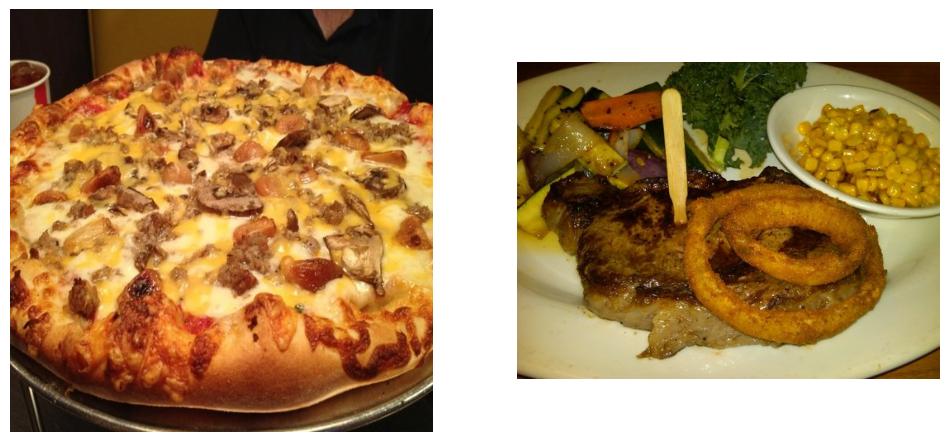

In [19]:
plt.figure(figsize=(12,8))
plt.subplot(1, 2, 1)
show_random_image('/content/pizza_steak/train', 'pizza')
plt.subplot(1, 2, 2)
show_random_image('/content/pizza_steak/train', 'steak')
plt.show()

In [20]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split

In [21]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

In [22]:
train_val_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform )

In [23]:
torch.manual_seed(42)
n_total = len(train_val_dataset)
n_valid = int(n_total * 0.10)
n_train  = n_total - n_valid

train_dataset, valid_dataset = random_split(
    train_val_dataset, [n_train, n_valid]
)

In [24]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [25]:
images , labels = next(iter(train_loader))

In [26]:
images.shape

torch.Size([32, 3, 224, 224])

In [27]:
labels[:10].tolist()

[1, 1, 1, 0, 1, 0, 0, 1, 1, 0]

In [28]:
def plot_image(image_tensor):
  img = image_tensor.permute(1, 2, 0).numpy()
  img = (img - img.min()) / (img.max() - img.min())
  plt.imshow(img)
  plt.axis(False)

In [29]:
class_names =  train_val_dataset.classes
class_names

['pizza', 'steak']

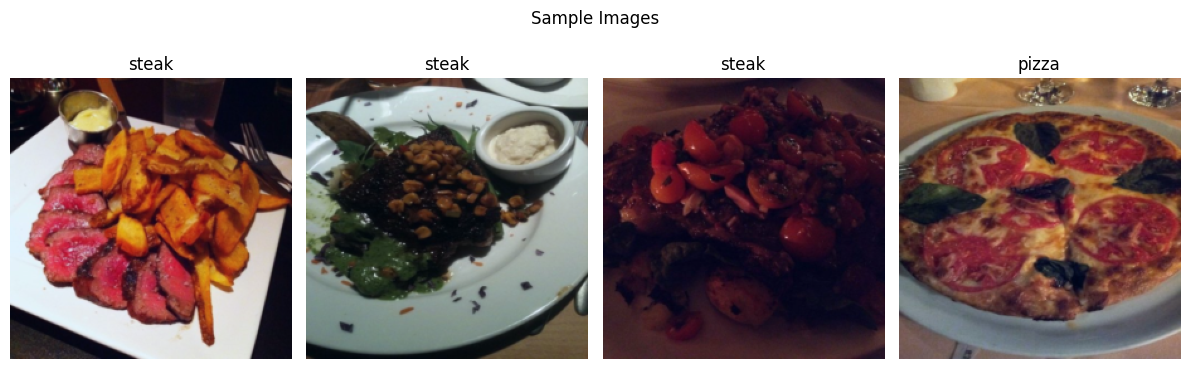

In [30]:
plt.figure(figsize=(12, 4))
for i in range(4):
  plt.subplot(1, 4, i+1)
  plot_image(images[i])
  plt.title(class_names[labels[i].item()])
plt.suptitle('Sample Images')
plt.tight_layout()
plt.show()

In [31]:
import torchvision.transforms.v2 as T

In [32]:
sample_images = images[:2]
cropped_images = T.CenterCrop((70, 120))(sample_images)
cropped_images.shape

torch.Size([2, 3, 70, 120])

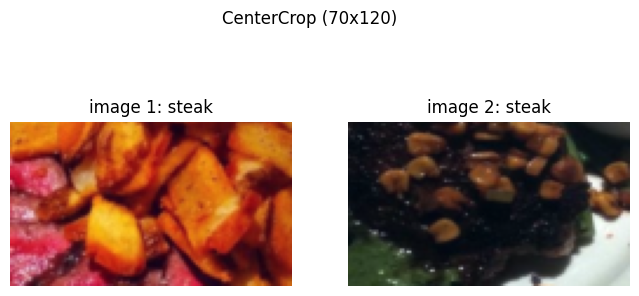

In [33]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plot_image(cropped_images[0])
plt.title(f'image 1: {class_names[labels[0].item()]}')
plt.subplot(1, 2, 2)
plot_image(cropped_images[1])
plt.title(f'image 2: {class_names[labels[1].item()]}')
plt.suptitle('CenterCrop (70x120)')
plt.show()

In [34]:
torch.manual_seed(42)
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7)
fmaps = conv_layer(cropped_images)
fmaps.shape

torch.Size([2, 32, 64, 114])

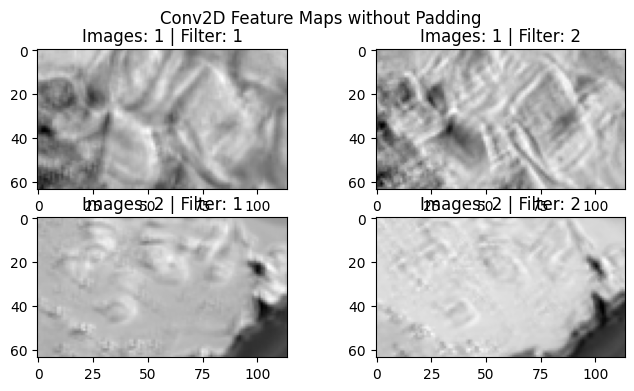

In [35]:
plt.figure(figsize=(8, 4))
for img_idx in (0, 1):
  for fmap_idx in (0,1):
    plt.subplot(2, 2, img_idx * 2 + fmap_idx +1)
    plt.imshow(fmaps[img_idx, fmap_idx].detach(), cmap='gray')
    plt.title(f'Images: {img_idx + 1} | Filter: {fmap_idx + 1}')
plt.suptitle('Conv2D Feature Maps without Padding')
plt.show()

In [36]:
conv_layer_same = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7, padding='same')
fmaps_same = conv_layer_same(cropped_images)
fmaps_same.shape

torch.Size([2, 32, 70, 120])

In [37]:
conv_layer_stride = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7,
                              padding=3, stride=2)
fmaps_stride = conv_layer_stride(cropped_images)
print(fmaps_stride.shape)
print(conv_layer_stride.weight.shape)
print(conv_layer_stride.bias.shape)

torch.Size([2, 32, 35, 60])
torch.Size([32, 3, 7, 7])
torch.Size([32])


In [38]:
import torch.nn.functional as F

torch.manual_seed(42)
filters = torch.randn([2, 3, 7, 7])
biases = torch.zeros([2])
fmaps_manual = F.conv2d(cropped_images, filters, biases, stride=1, padding='same')
fmaps_manual.shape

torch.Size([2, 2, 70, 120])

In [39]:
filtres = torch.zeros([2, 3, 7, 7])
filters[0, :, :, 3] = 1
filtres[1, :, 3, :] = 1

fmaps_edge = F.conv2d(cropped_images, filters, biases, stride=1, padding='same')
fmaps_edge.shape

torch.Size([2, 2, 70, 120])

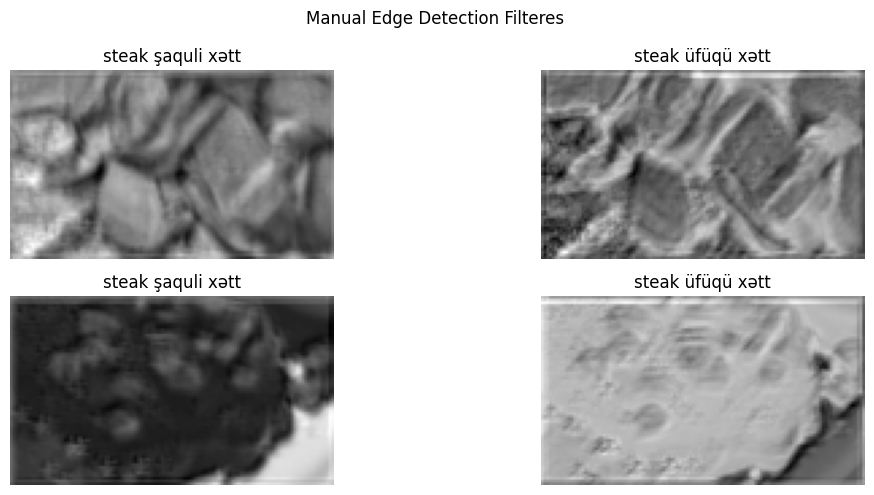

In [40]:
plt.figure(figsize=(12,5))

for img_idx in (0,1):
  for fmap_idx in (0,1):
    plt.subplot(2, 2, img_idx * 2 + fmap_idx + 1)
    plt.imshow(fmaps_edge[img_idx, fmap_idx].detach(), cmap='gray')
    title = 'şaquli xətt' if fmap_idx == 0 else 'üfüqü xətt'
    plt.title(f'{class_names[labels[img_idx].item()]} {title}')
    plt.axis('off')
plt.suptitle("Manual Edge Detection Filteres ")
plt.tight_layout()
plt.show()

# Pooling

In [41]:
max_pool = nn.MaxPool2d(kernel_size=2)

In [42]:
output_max = max_pool(cropped_images)

In [43]:
avg_pool = nn.AvgPool2d(kernel_size=2)

In [44]:
output_avg = avg_pool(cropped_images)

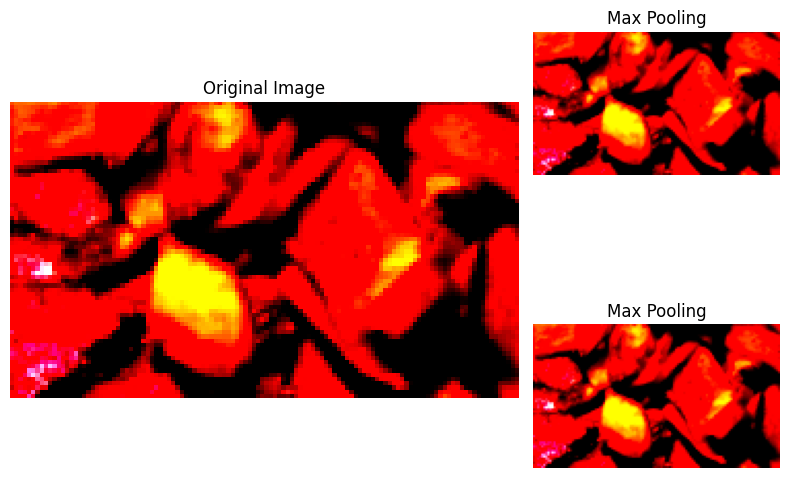

In [45]:
fig = plt.figure(figsize=(8, 6))

ax1 = plt.subplot2grid((2, 3), (0,0), rowspan=2, colspan=2)
ax1.imshow(cropped_images[0].permute(1,2,0))
ax1.axis('off')
ax1.set_title('Original Image')


ax2 = plt.subplot2grid((2, 3), (0,2))
ax2.imshow(cropped_images[0].permute(1,2,0))
ax2.axis('off')
ax2.set_title('Max Pooling')


ax3 = plt.subplot2grid((2, 3), (1,2))
ax3.imshow(cropped_images[0].permute(1,2,0))
ax3.axis('off')
ax3.set_title('Max Pooling')

plt.tight_layout()
plt.show()

In [46]:
import torch.nn.functional as F

class DepthMaxPool2(torch.nn.Module):
  def __init__(self, kernel_size, stride=None, padding=0):
    super().__init__()
    self.kernel_size = kernel_size
    self.stride = stride if stride is not None else kernel_size
    self.padding = padding

  def forward(self, inputs):
    batch, channels, height, width = inputs.shape
    Z = inputs.view(batch, channels, height * width)
    Z = Z.permute(0, 2, 1)
    Z = F.max_pool1d(Z, kernel_size=self.kernel_size, stride=self.stride, padding=self.padding)
    Z = Z.permute(0, 2, 1)
    return Z.view(batch, -1, height, width)

In [47]:
global_avg_pool = nn.AvgPool2d(kernel_size=(70, 120))

In [48]:
output = global_avg_pool(cropped_images)
output

tensor([[[[ 0.7373]],

         [[-0.9215]],

         [[-1.4604]]],


        [[[-1.2079]],

         [[-1.2831]],

         [[-1.3415]]]])

In [49]:
global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1)

In [50]:
output = global_avg_pool(cropped_images)
output

tensor([[[[ 0.7373]],

         [[-0.9215]],

         [[-1.4604]]],


        [[[-1.2079]],

         [[-1.2831]],

         [[-1.3415]]]])

In [51]:
output = cropped_images.mean(dim=(2, 3), keepdim=True)
output

tensor([[[[ 0.7373]],

         [[-0.9215]],

         [[-1.4604]]],


        [[[-1.2079]],

         [[-1.2831]],

         [[-1.3415]]]])

# CNN

In [52]:
from functools import partial
import torch
import torch.nn as nn

torch.manual_seed(42)
DefaultConv2d = partial(nn.Conv2d, kernel_size=3, padding='same')
model = nn.Sequential(
    DefaultConv2d(in_channels=3, out_channels=64, kernel_size=7),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    DefaultConv2d(in_channels=64, out_channels=128),
    nn.ReLU(),
    DefaultConv2d(in_channels=128, out_channels=128),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    DefaultConv2d(in_channels=128, out_channels=256),
    nn.ReLU(),
    DefaultConv2d(in_channels=256, out_channels=256),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Flatten(),
    nn.Linear(in_features=256 * 28 * 28, out_features=128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=128, out_features=64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=64, out_features=1),
    nn.Sigmoid()
).to(device)

In [53]:
!pip install torchmetrics

In [54]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
  model.eval()
  metric.reset()
  with torch.no_grad():
    for X_batch, y_batch in data_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      metric.update(y_pred, y_batch.float().view(-1, 1))
  return metric.compute()

In [55]:
def train(model, optimizer, loss_fn, metric, train_loader, valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch.float().view(-1, 1))
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch.float().view(-1, 1))
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch+1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train acc: {history['train_metrics'][-1]:.4f}, "
              f"valid acc: {history['valid_metrics'][-1]:.4f}")
    return history

In [56]:
n_epochs = 20
optimizer = torch.optim.Adam(model.parameters())
bce_loss = nn.BCELoss()
accuracy = torchmetrics.Accuracy(task='binary').to(device)

history = train(model, optimizer, bce_loss, accuracy, train_loader, valid_loader, n_epochs)

Epoch 1/20, train loss: 0.6979, train acc: 0.5393, valid acc: 0.6533
Epoch 2/20, train loss: 0.5900, train acc: 0.6933, valid acc: 0.7600
Epoch 3/20, train loss: 0.5601, train acc: 0.7467, valid acc: 0.7133
Epoch 4/20, train loss: 0.5100, train acc: 0.7637, valid acc: 0.8067
Epoch 5/20, train loss: 0.4704, train acc: 0.7896, valid acc: 0.7867
Epoch 6/20, train loss: 0.4520, train acc: 0.8030, valid acc: 0.8333
Epoch 7/20, train loss: 0.3994, train acc: 0.8341, valid acc: 0.7867
Epoch 8/20, train loss: 0.4266, train acc: 0.8126, valid acc: 0.8267
Epoch 9/20, train loss: 0.3438, train acc: 0.8585, valid acc: 0.8333
Epoch 10/20, train loss: 0.3138, train acc: 0.8719, valid acc: 0.8133
Epoch 11/20, train loss: 0.2820, train acc: 0.8933, valid acc: 0.8533
Epoch 12/20, train loss: 0.2496, train acc: 0.9059, valid acc: 0.7867
Epoch 13/20, train loss: 0.2482, train acc: 0.9007, valid acc: 0.8133
Epoch 14/20, train loss: 0.2126, train acc: 0.9133, valid acc: 0.8133
Epoch 15/20, train loss: 0.18

# LeNet architecture

In [57]:
class LeNet(nn.Module):
  def __init__(self, input_size=3):
    super().__init__()
    self.model = nn.Sequential(
        nn.Conv2d(input_size, 6, kernel_size=5, padding='same'),
        nn.Tanh(),
        nn.AvgPool2d(kernel_size=2, stride=2),
        nn.Conv2d(6, 16, kernel_size=5),
        nn.Tanh(),
        nn.AvgPool2d(kernel_size=2, stride=2),
        nn.Conv2d(16, 120, kernel_size=5),
        nn.Flatten(),
        nn.Linear(120 * 50 * 50, 84),
        nn.Tanh(),
        nn.Linear(84, 1),
        nn.Sigmoid() )
  def forward(self, X):
    return self.model(X)

In [58]:
def train_lenet(model, optimizer, loss_fn, train_loader, epochs):
  for epoch in range(epochs):
      total_loss = 0.
      for X_batch, y_batch in train_loader:
          X_batch, y_batch = X_batch.to(device), y_batch.to(device)
          y_pred = model(X_batch)
          loss = loss_fn(y_pred, y_batch.float().view(-1, 1))
          total_loss += loss.item()
          loss.backward()
          optimizer.step()
          optimizer.zero_grad()
      print(f'Epoch: {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}')

In [59]:
model_lenet = LeNet(3).to(device)
optimizer = torch.optim.AdamW(model_lenet.parameters(), lr=1e-3)
train_lenet(model_lenet, optimizer, nn.BCELoss(), train_loader, epochs=20)

Epoch: 1/20, Loss: 0.9949
Epoch: 2/20, Loss: 0.5164
Epoch: 3/20, Loss: 0.5262
Epoch: 4/20, Loss: 0.5356
Epoch: 5/20, Loss: 0.5197
Epoch: 6/20, Loss: 0.5151
Epoch: 7/20, Loss: 0.5127
Epoch: 8/20, Loss: 0.5479
Epoch: 9/20, Loss: 0.5039
Epoch: 10/20, Loss: 0.4990
Epoch: 11/20, Loss: 0.5110
Epoch: 12/20, Loss: 0.5300
Epoch: 13/20, Loss: 0.5396
Epoch: 14/20, Loss: 0.5214
Epoch: 15/20, Loss: 0.5251
Epoch: 16/20, Loss: 0.5156
Epoch: 17/20, Loss: 0.5020
Epoch: 18/20, Loss: 0.5110
Epoch: 19/20, Loss: 0.5166
Epoch: 20/20, Loss: 0.5201


In [60]:
images, labels = next(iter(train_loader))
new_data = images[:3].to(device)
preds= model_lenet(new_data)
predicted_classes = (preds > 0.5).long().squeeze()
print(f'Predictions:', [class_names [i] for i in predicted_classes])
print(f'Real', [class_names [i] for i in labels[:3]])

Predictions: ['steak', 'steak', 'pizza']
Real ['steak', 'steak', 'pizza']


# SeperableConv2D

In [61]:
class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super().__init__()
        self.depthwise_conv = nn.Conv2d(
            in_channels, in_channels, kernel_size,
            stride=stride, padding=padding, groups=in_channels)
        self.pointwise_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, inputs):
        return self.pointwise_conv(self.depthwise_conv(inputs))

# Resnet-34 architecture

In [62]:
class ResidualUnit(nn.Module):
  def __init__(self, in_channels, out_channels, stride=1):
    super().__init__()
    DefaultConv2d = partial(nn.Conv2d, kernel_size=3, padding=1, stride=1, bias=False)

    self.main_layers = nn.Sequential(
        DefaultConv2d(in_channels, out_channels, stride=stride),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),
        DefaultConv2d(out_channels, out_channels),
        nn.BatchNorm2d(out_channels)
    )

    if stride > 1:
      self.skip_connection = nn.Sequential(
          nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, padding=0, bias=False),
          nn.BatchNorm2d(out_channels)
      )
    else:
      self.skip_connection = nn.Identity()

  def forward(self, inputs):
    return F.relu(self.main_layers(inputs) + self.skip_connection(inputs))

In [63]:
class ResNet34(nn.Module):
  def __init__(self):
    super().__init__()
    layers = [
        nn.Conv2d(in_channels=3, out_channels=64, kernel_size=7, stride=2, padding=3, bias=False),
        nn.BatchNorm2d(num_features=64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
    ]

    prev_filters = 64
    for filters in [64] * 3 + [128] * 4 + [256] * 6 + [512] * 3:
      stride = 1 if filters == prev_filters else 2
      layers.append(ResidualUnit(prev_filters, filters, stride=stride))
      prev_filters = filters
    layers += [
        nn.AdaptiveAvgPool2d(output_size=1),
        nn.Flatten(),
        nn.LazyLinear(1)
    ]
    self.resnet = nn.Sequential(*layers)

  def forward(self, inputs):
    return self.resnet(inputs)

In [64]:
torch.manual_seed(42)
model_resnet = ResNet34().to(device)

In [65]:
images = torch.randn(2, 3, 224, 224).to(device)
model_resnet(images)

tensor([[0.2233],
        [0.2202]], device='cuda:0', grad_fn=<AddmmBackward0>)

# TorchVision's Pretrained Models

In [66]:
weights = torchvision.models.ConvNeXt_Base_Weights.IMAGENET1K_V1
model_convnext = torchvision.models.convnext_base(weights=weights).to(device)

Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:04<00:00, 85.6MB/s]


In [67]:
torchvision.models.list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [68]:
transforms = weights.transforms()
preprocessed_images = transforms(cropped_images)

In [69]:
model.eval()
with torch.no_grad():
  y_logits = model_convnext(preprocessed_images.to(device))

In [70]:
y_preds = torch.argmax(y_logits, dim=1)
y_preds

tensor([766, 493], device='cuda:0')

# Transfer Learning

In [71]:
model_convnext.classifier[2] = nn.Sequential(
    nn.Linear(1024, 1),
    nn.Sigmoid()
).to(device)

In [72]:
for param in model_convnext.parameters():
    param.requires_grad = False
for param in model_convnext.classifier.parameters():
    param.requires_grad = True

In [73]:
n_epochs = 5
optimizer = torch.optim.Adam(model_convnext.parameters())
accuracy = torchmetrics.Accuracy(task="binary").to(device)
history = train(model_convnext, optimizer, nn.BCELoss(), accuracy, train_loader, test_loader, n_epochs)

Epoch 1/5, train loss: 0.2699, train acc: 0.9422, valid acc: 0.9980
Epoch 2/5, train loss: 0.0835, train acc: 0.9770, valid acc: 0.9980
Epoch 3/5, train loss: 0.0609, train acc: 0.9822, valid acc: 0.9980
Epoch 4/5, train loss: 0.0484, train acc: 0.9844, valid acc: 0.9980
Epoch 5/5, train loss: 0.0483, train acc: 0.9852, valid acc: 0.9980


In [74]:
for param in model_convnext.parameters():
    param.requires_grad = True

In [75]:
history = train(model_convnext, optimizer, nn.BCELoss(), accuracy,
                train_loader, test_loader, n_epochs)

Epoch 1/5, train loss: 1.0506, train acc: 0.6156, valid acc: 0.6140
Epoch 2/5, train loss: 0.5394, train acc: 0.7467, valid acc: 0.8480
Epoch 3/5, train loss: 0.4558, train acc: 0.7970, valid acc: 0.9200
Epoch 4/5, train loss: 0.3896, train acc: 0.8452, valid acc: 0.9120
Epoch 5/5, train loss: 0.3965, train acc: 0.8370, valid acc: 0.9060


# Data Augmentation

In [76]:
import torchvision.transforms.v2 as T

augmented_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=30),
    T.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [77]:
from torchvision import datasets
train_dataset_aug = datasets.ImageFolder(root=train_dir, transform=augmented_transform)
train_loader_aug  = DataLoader(train_dataset_aug, batch_size=32, shuffle=True)

# Classification and Localization

In [78]:
def denormalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    return (image * torch.tensor(std).view(-1, 1, 1) + torch.tensor(mean).view(-1, 1, 1))

In [79]:
class PizzaSteakLocator(nn.Module):
    def __init__(self, base_model, in_features):
        super().__init__()
        self.base_model = base_model
        self.localization_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, 4)
        )

    def forward(self, X):
        features = self.base_model.features(X)
        pool = self.base_model.avgpool(features)
        y_pred_logits = self.base_model.classifier(pool)
        y_pred_bbox = self.localization_head(pool)
        return y_pred_logits, y_pred_bbox

In [80]:
torch.manual_seed(42)
locator_model = PizzaSteakLocator(model_convnext, in_features=1024).to(device)

sample_batch = images[:2].to(device)
y_pred_logits, y_pred_bbox = locator_model(sample_batch)
print("logits shape:", y_pred_logits.shape)
print("bbox shape:  ", y_pred_bbox.shape)

logits shape: torch.Size([2, 1])
bbox shape:   torch.Size([2, 4])


In [81]:
import torchvision.tv_tensors

raw_train_dataset = datasets.ImageFolder(root=train_dir)

pizza_class_idx = class_names.index('pizza')
steak_class_idx = class_names.index('steak')

def first_index_of_class(dataset, class_idx):
    for i, (_, label) in enumerate(dataset.samples):
        if label == class_idx:
            return i
    raise ValueError("No image found!")

pizza_index = first_index_of_class(raw_train_dataset, pizza_class_idx)
steak_index = first_index_of_class(raw_train_dataset, steak_class_idx)

pizza_image, pizza_label = raw_train_dataset[pizza_index]
steak_image, steak_label = raw_train_dataset[steak_index]

print("pizza index:", pizza_index, "size:", pizza_image.size)
print("steak index:", steak_index, "size:", steak_image.size)

pizza index: 0 size: (512, 384)
steak index: 750 size: (512, 384)


In [82]:
def make_demo_bbox(image):
    w, h = image.size
    return torchvision.tv_tensors.BoundingBoxes(
        [[w / 2, h / 2, w * 0.7, h * 0.7]],
        format="CXCYWH",
        canvas_size=(h, w)
    )

pizza_bbox = make_demo_bbox(pizza_image)
steak_bbox = make_demo_bbox(steak_image)

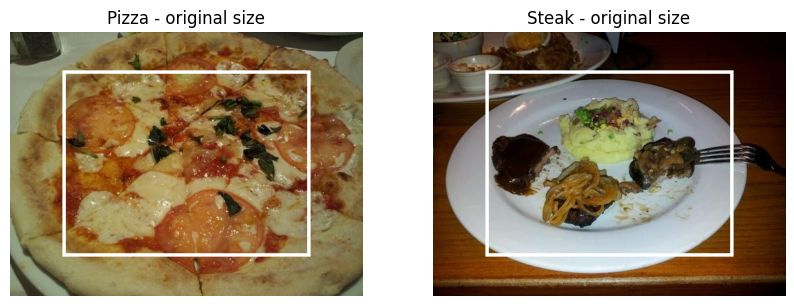

In [83]:
def get_image_with_bbox(image, bbox, width=5, color="white"):
    bbox_xyxy = torchvision.ops.box_convert(bbox, "cxcywh", "xyxy")
    return torchvision.utils.draw_bounding_boxes(image, bbox_xyxy, width=width, colors=color)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plt.sca(axes[0])
plot_image(get_image_with_bbox(T.ToImage()(pizza_image), pizza_bbox))
plt.title("Pizza - original size")

plt.sca(axes[1])
plot_image(get_image_with_bbox(T.ToImage()(steak_image), steak_bbox))
plt.title("Steak - original size")

plt.show()

In [84]:
locator_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

torch.manual_seed(42)
pizza_preproc_image, pizza_preproc_target = locator_transform(
    (pizza_image, {"label": pizza_label, "bbox": pizza_bbox}))
pizza_preproc_bbox = pizza_preproc_target["bbox"]

torch.manual_seed(42)
steak_preproc_image, steak_preproc_target = locator_transform(
    (steak_image, {"label": steak_label, "bbox": steak_bbox}))
steak_preproc_bbox = steak_preproc_target["bbox"]

print(pizza_preproc_image.shape, pizza_preproc_bbox)
print(steak_preproc_image.shape, steak_preproc_bbox)

torch.Size([3, 224, 224]) BoundingBoxes([[112.0000, 112.0000, 156.8000, 156.8000]], format=BoundingBoxFormat.CXCYWH, canvas_size=(224, 224), clamping_mode=soft)
torch.Size([3, 224, 224]) BoundingBoxes([[112.0000, 112.0000, 156.8000, 156.8000]], format=BoundingBoxFormat.CXCYWH, canvas_size=(224, 224), clamping_mode=soft)


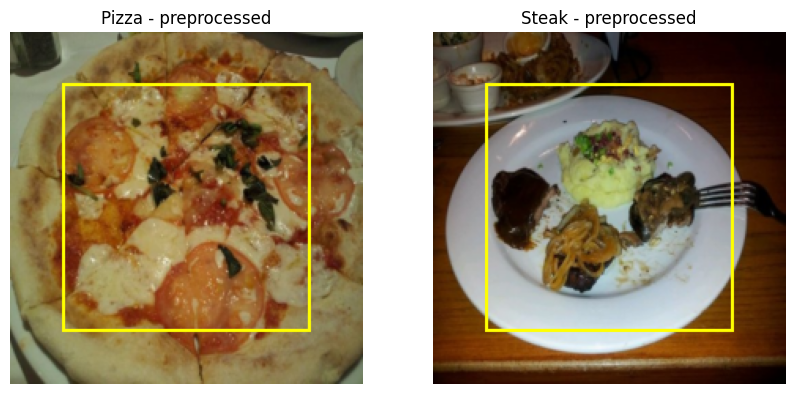

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plt.sca(axes[0])
plot_image(get_image_with_bbox(denormalize(pizza_preproc_image), pizza_preproc_bbox, width=2, color="yellow"))
plt.title("Pizza - preprocessed")

plt.sca(axes[1])
plot_image(get_image_with_bbox(denormalize(steak_preproc_image), steak_preproc_bbox, width=2, color="yellow"))
plt.title("Steak - preprocessed")

plt.show()

In [86]:
class PizzaSteakWithBBox(torch.utils.data.Dataset):
    def __init__(self, root, indices, bboxes, transform=None):
        self.image_dataset = datasets.ImageFolder(root=root)
        self.indices = indices
        self.bboxes = bboxes
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        raw_image, label = self.image_dataset[self.indices[i]]
        bbox = self.bboxes[i]
        preproc_image, preproc_target = self.transform((raw_image, {"label": label, "bbox": bbox}))
        return preproc_image, preproc_target

In [87]:
demo_dataset = PizzaSteakWithBBox(
    train_dir,
    indices=[pizza_index, steak_index],
    bboxes=[pizza_bbox, steak_bbox],
    transform=locator_transform
)
demo_loader = DataLoader(demo_dataset, batch_size=2)

for imgs, targets in demo_loader:
    print(imgs.shape, targets["label"], targets["bbox"].shape)

torch.Size([2, 3, 224, 224]) tensor([0, 1]) torch.Size([2, 1, 4])


# Object Detection

In [88]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 kB 7.7 MB/s eta 0:00:00


In [89]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [90]:
yolo_model = YOLO("yolov9m.pt")

pizza_dir  = train_dir / 'pizza'
steak_dir  = train_dir / 'steak'


sample_pizza_paths = [str(pizza_dir / f) for f in os.listdir(pizza_dir)[:3]]
sample_steak_paths = [str(steak_dir / f) for f in os.listdir(steak_dir)[:3]]

results_pizza = yolo_model(sample_pizza_paths)
results_steak = yolo_model(sample_steak_paths)


0: 640x640 1 pizza, 34.4ms
1: 640x640 4 bottles, 4 pizzas, 34.4ms
2: 640x640 1 spoon, 4 pizzas, 1 dining table, 34.4ms
Speed: 5.6ms preprocess, 34.4ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 31.8ms
1: 640x640 1 cake, 31.8ms
2: 640x640 2 spoons, 3 bowls, 1 sandwich, 31.8ms
Speed: 1.9ms preprocess, 31.8ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


In [91]:
results_pizza[0].to_df()

name,class,confidence,box
str,i64,f64,struct[4]
"""pizza""",53,0.94403,"{35.14819,1.75488,511.22202,380.04428}"


In [92]:
results_steak[0].to_df()

shape: (0, 0)
┌┐
╞╡
└┘

In [93]:
print('Pizza:' , results_pizza[0].summary()[0])
print('Steak:' , results_steak[0].summary())

Pizza: {'name': 'pizza', 'class': 53, 'confidence': 0.94403, 'box': {'x1': 35.14819, 'y1': 1.75488, 'x2': 511.22202, 'y2': 380.04428}}
Steak: []


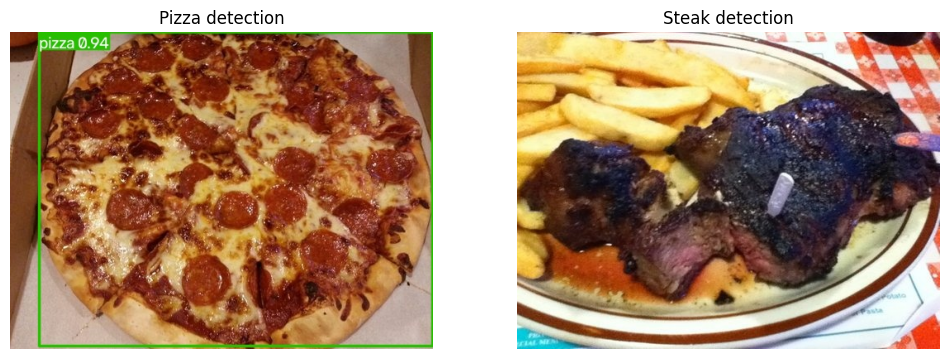

In [94]:
import PIL

results_pizza[0].save('annotated_pizza_1.jpg')
results_steak[0].save('annotated_steak_1.jpg')

fig , axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(PIL.Image.open('annotated_pizza_1.jpg'))
axes[0].axis('off')
axes[0].set_title('Pizza detection')


axes[1].imshow(PIL.Image.open('annotated_steak_1.jpg'))
axes[1].axis('off')
axes[1].set_title('Steak detection')

plt.show()

# Semantic Segmentation

In [95]:
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights

seg_weights = FCN_ResNet50_Weights.DEFAULT
seg_model = fcn_resnet50(Weights=seg_weights).to(device)
seg_model.eval()

seg_transform = seg_weights.transforms()
voc_classes = seg_weights.meta['categories']
background_id = voc_classes.index('__background__')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 182MB/s]


In [96]:
def run_segmentation(image_path):
    img = PIL.Image.open(image_path).convert("RGB")
    batch = seg_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        seg_out = seg_model(batch)["out"].softmax(dim=1)

    foreground_mask = 1 - seg_out[0, background_id]
    original = denormalize(batch.squeeze(0).cpu()).clamp(0, 1)
    fg_mask_cpu = foreground_mask.unsqueeze(0).cpu()
    green_bg = torch.tensor([0.0, 1.0, 0.0]).view(3, 1, 1)
    background_mask = 1.0 - fg_mask_cpu
    masked_image = (fg_mask_cpu * original + background_mask * green_bg).clamp(0, 1)

    return original, foreground_mask.cpu(), masked_image

In [97]:
def plot_segmentation_row(axes_row, image_path, label):
  original, mask, masked = run_segmentation(image_path)

  axes_row[0].imshow(original.permute(1, 2, 0).numpy())
  axes_row[0].axis('off')
  axes_row[0].set_title(f'{label} - original')


  axes_row[1].imshow(mask, cmap='binary')
  axes_row[1].axis('off')
  axes_row[1].set_title(f'{label} - mask')

  axes_row[2].imshow(masked.permute(1, 2, 0).numpy())
  axes_row[2].axis('off')
  axes_row[2].set_title(f'{label} - masked')

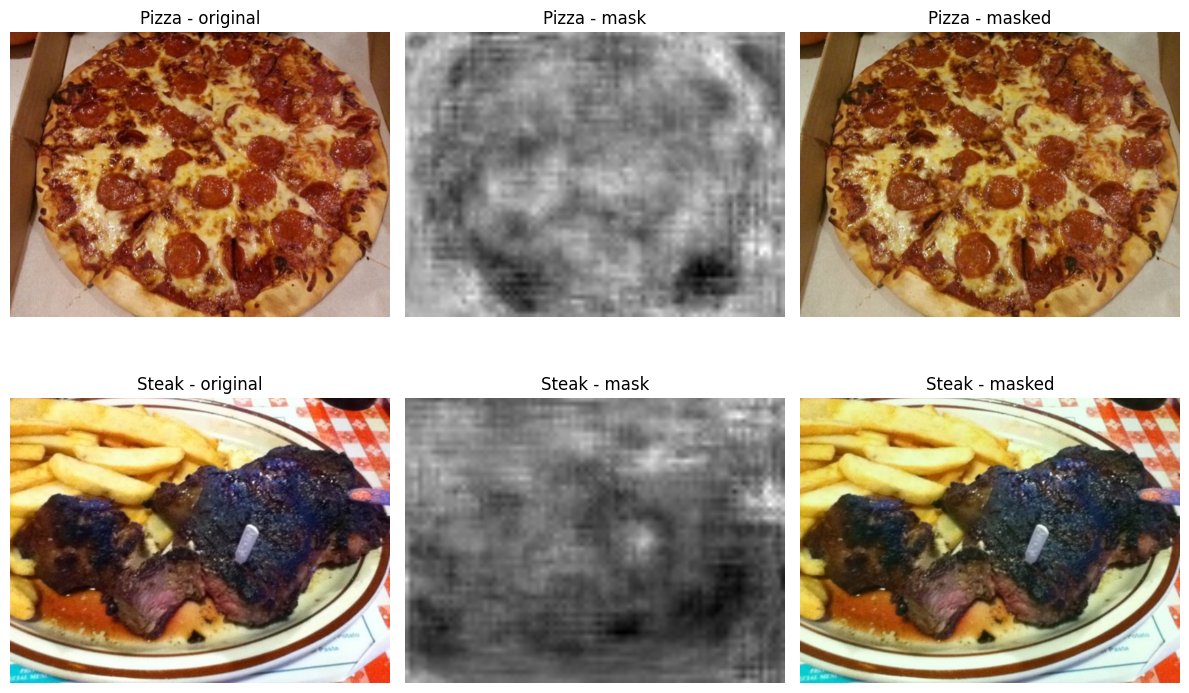

In [98]:
fig , axes = plt.subplots(2, 3, figsize=(12, 8))
plot_segmentation_row(axes[0], sample_pizza_paths[0], "Pizza")
plot_segmentation_row(axes[1], sample_steak_paths[0], "Steak")

plt.tight_layout()
plt.show()